# Phase 2: Data Processing & Preprocessing
See PHASE2_DOCUMENTATION.txt for detailed explanations.

## Section 1: Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("âœ“ All libraries imported successfully")

âœ“ All libraries imported successfully


## Step 2: Load and Explore Dataset

In [34]:
# Load merged dataset
df = pd.read_csv('../data/interim/merged_livable_cities.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nShape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
print(df.head())

DATASET OVERVIEW

Shape: (150, 17)

Data Types:
Rank                                        int64
City                                          str
Country                                       str
Purchasing Power Index                    float64
Safety Index                              float64
Health Care Index                         float64
Cost of Living Index                      float64
Property Price to Income Ratio            float64
Traffic Commute Time Index                float64
Pollution Index                           float64
Climate Index                             float64
Meal, Inexpensive Restaurant (USD)        float64
Average Monthly Net Salary (After Tax)    float64
Air_Pollution_2023                        float64
Education                                 float64
Taxation                                  float64
Internet Access                           float64
dtype: object

First 5 rows:
   Rank       City               Country  Purchasing Power Index  \
0   1

In [35]:
print("\nDataset Information:")
print(df.info())
print(f"\nBasic Statistics:")
print(df.describe())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Rank                                    150 non-null    int64  
 1   City                                    150 non-null    str    
 2   Country                                 150 non-null    str    
 3   Purchasing Power Index                  150 non-null    float64
 4   Safety Index                            150 non-null    float64
 5   Health Care Index                       150 non-null    float64
 6   Cost of Living Index                    150 non-null    float64
 7   Property Price to Income Ratio          150 non-null    float64
 8   Traffic Commute Time Index              150 non-null    float64
 9   Pollution Index                         150 non-null    float64
 10  Climate Index                           150 non-nul

## Section 2: Load Dataset

In [36]:
print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

# Calculate missing values statistics
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_stats_sorted = missing_stats[missing_stats['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"\nMissing Value Summary:\n{missing_stats_sorted}")
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

MISSING VALUE ANALYSIS

Missing Value Summary:
                                                                        Column  \
Internet Access                                                Internet Access   
Education                                                            Education   
Taxation                                                              Taxation   
Air_Pollution_2023                                          Air_Pollution_2023   
Average Monthly Net Salary (After Tax)  Average Monthly Net Salary (After Tax)   
Meal, Inexpensive Restaurant (USD)          Meal, Inexpensive Restaurant (USD)   

                                        Missing Count  Missing %  
Internet Access                                    27      18.00  
Education                                          26      17.33  
Taxation                                           26      17.33  
Air_Pollution_2023                                 14       9.33  
Average Monthly Net Salary (After Tax)     

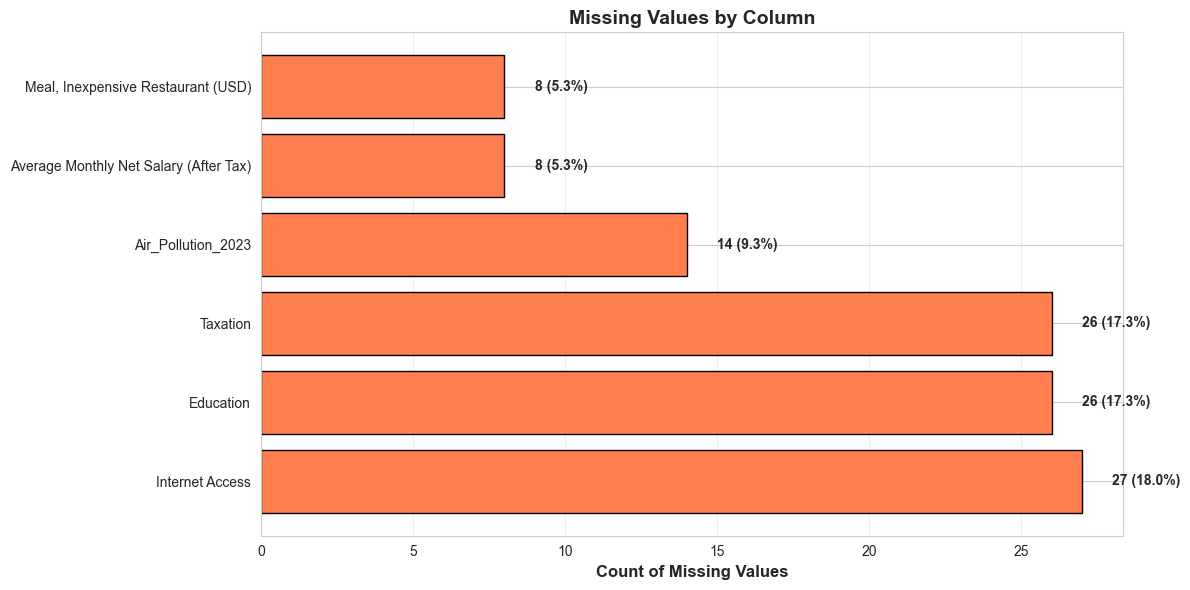

âœ“ Saved: missing_values_analysis.png


In [37]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

bars = ax.barh(missing_data.index, missing_data.values, color='coral', edgecolor='black')
ax.set_xlabel('Count of Missing Values', fontsize=12, fontweight='bold')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (col, val) in enumerate(missing_data.items()):
    pct = (val / len(df) * 100)
    ax.text(val + 1, i, f'{int(val)} ({pct:.1f}%)', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/phase2/missing_values_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("âœ“ Saved: missing_values_analysis.png")

## Section 3: Missing Value Analysis

In [38]:
# Feature categorization
core_features = [
    'Purchasing Power Index', 'Safety Index',
    'Health Care Index', 'Cost of Living Index', 'Property Price to Income Ratio',
    'Traffic Commute Time Index', 'Pollution Index', 'Climate Index'
]
sparse_features = ['Meal, Inexpensive Restaurant (USD)', 'Average Monthly Net Salary (After Tax)', 'Air_Pollution_2023', 'Education', 'Taxation', 'Internet Access']
all_numeric_features = core_features + sparse_features

print(f"Core: {len(core_features)} | Sparse: {len(sparse_features)} | Total: {len(all_numeric_features)}")

Core: 8 | Sparse: 6 | Total: 14


In [39]:
# Verify completeness
print("\n" + "=" * 80)
print("FEATURE COMPLETENESS CHECK")
print("=" * 80)

print(f"\nCore Features Completeness:")
for col in core_features:
    complete = df[col].notna().sum()
    total = len(df)
    pct = complete / total * 100
    print(f"  {col:40s}: {complete:3d}/{total} ({pct:5.1f}%)")

print(f"\nSparse Features Completeness:")
for col in sparse_features:
    complete = df[col].notna().sum()
    total = len(df)
    pct = complete / total * 100
    print(f"  {col:40s}: {complete:3d}/{total} ({pct:5.1f}%)")


FEATURE COMPLETENESS CHECK

Core Features Completeness:
  Purchasing Power Index                  : 150/150 (100.0%)
  Safety Index                            : 150/150 (100.0%)
  Health Care Index                       : 150/150 (100.0%)
  Cost of Living Index                    : 150/150 (100.0%)
  Property Price to Income Ratio          : 150/150 (100.0%)
  Traffic Commute Time Index              : 150/150 (100.0%)
  Pollution Index                         : 150/150 (100.0%)
  Climate Index                           : 150/150 (100.0%)

Sparse Features Completeness:
  Meal, Inexpensive Restaurant (USD)      : 142/150 ( 94.7%)
  Average Monthly Net Salary (After Tax)  : 142/150 ( 94.7%)
  Air_Pollution_2023                      : 136/150 ( 90.7%)
  Education                               : 124/150 ( 82.7%)
  Taxation                                : 124/150 ( 82.7%)
  Internet Access                         : 123/150 ( 82.0%)


## Section 4: Define Feature Categories

In [40]:
print("=" * 80)
print("MISSING VALUE HANDLING - COUNTRY-WISE MEAN IMPUTATION")
print("=" * 80)

df_processed = df.copy()

print("\nApplying country-wise mean imputation for sparse features...\n")

# Step 1: Country-wise mean imputation
for col in sparse_features:
    missing_before = df_processed[col].isnull().sum()

    if missing_before > 0:
        # Fill missing values using country-wise mean
        country_mean = df_processed.groupby('Country')[col].transform('mean')
        df_processed[col] = df_processed[col].fillna(country_mean)

        missing_after_country = df_processed[col].isnull().sum()
        print(f"{col}:")
        print(f"  Missing before: {missing_before}")
        print(f"  Missing after country-wise imputation: {missing_after_country}")

        # Step 2: Fill unresolved missing values with 0
        if missing_after_country > 0:
            df_processed[col] = df_processed[col].fillna(0)
            print(f"  Missing after 0 fallback: {df_processed[col].isnull().sum()}")
        print()

print(f"\n{'='*80}")
print(f"Total missing values in processed dataset: {df_processed.isnull().sum().sum()}")
print(f"{'='*80}")

MISSING VALUE HANDLING - COUNTRY-WISE MEAN IMPUTATION

Applying country-wise mean imputation for sparse features...

Meal, Inexpensive Restaurant (USD):
  Missing before: 8
  Missing after country-wise imputation: 3
  Missing after 0 fallback: 0

Average Monthly Net Salary (After Tax):
  Missing before: 8
  Missing after country-wise imputation: 3
  Missing after 0 fallback: 0

Air_Pollution_2023:
  Missing before: 14
  Missing after country-wise imputation: 6
  Missing after 0 fallback: 0

Education:
  Missing before: 26
  Missing after country-wise imputation: 5
  Missing after 0 fallback: 0

Taxation:
  Missing before: 26
  Missing after country-wise imputation: 5
  Missing after 0 fallback: 0

Internet Access:
  Missing before: 27
  Missing after country-wise imputation: 5
  Missing after 0 fallback: 0


Total missing values in processed dataset: 0


## Section 5: Handle Missing Values (Country-wise Mean)

In [41]:
print("=" * 80)
print("OUTLIER DETECTION (IQR METHOD - 1.5 * IQR)")
print("=" * 80)
print("\nDecision: Keep outliers as-is (they represent real-world extremes)\n")

outlier_summary = {}

for col in all_numeric_features:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)]
    outlier_summary[col] = {
        'outlier_count': len(outliers),
        'outlier_percentage': len(outliers) / len(df_processed) * 100,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'min': df_processed[col].min(),
        'max': df_processed[col].max()
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df_sorted = outlier_df[outlier_df['outlier_count'] > 0].sort_values('outlier_count', ascending=False)

print(f"Features with outliers detected:")
print(outlier_df_sorted[['outlier_count', 'outlier_percentage', 'min', 'max']].to_string())
print(f"\nTotal features with outliers: {len(outlier_df_sorted)} / {len(all_numeric_features)}")

OUTLIER DETECTION (IQR METHOD - 1.5 * IQR)

Decision: Keep outliers as-is (they represent real-world extremes)

Features with outliers detected:
                                outlier_count  outlier_percentage   min     max
Air_Pollution_2023                       12.0            8.000000   0.0  92.700
Taxation                                 11.0            7.333333   0.0  10.000
Internet Access                           7.0            4.666667   0.0   9.716
Property Price to Income Ratio            6.0            4.000000   2.0  37.200
Climate Index                             5.0            3.333333  20.2  99.900
Traffic Commute Time Index                3.0            2.000000  18.2  59.400
Health Care Index                         1.0            0.666667  47.7  86.600

Total features with outliers: 7 / 14


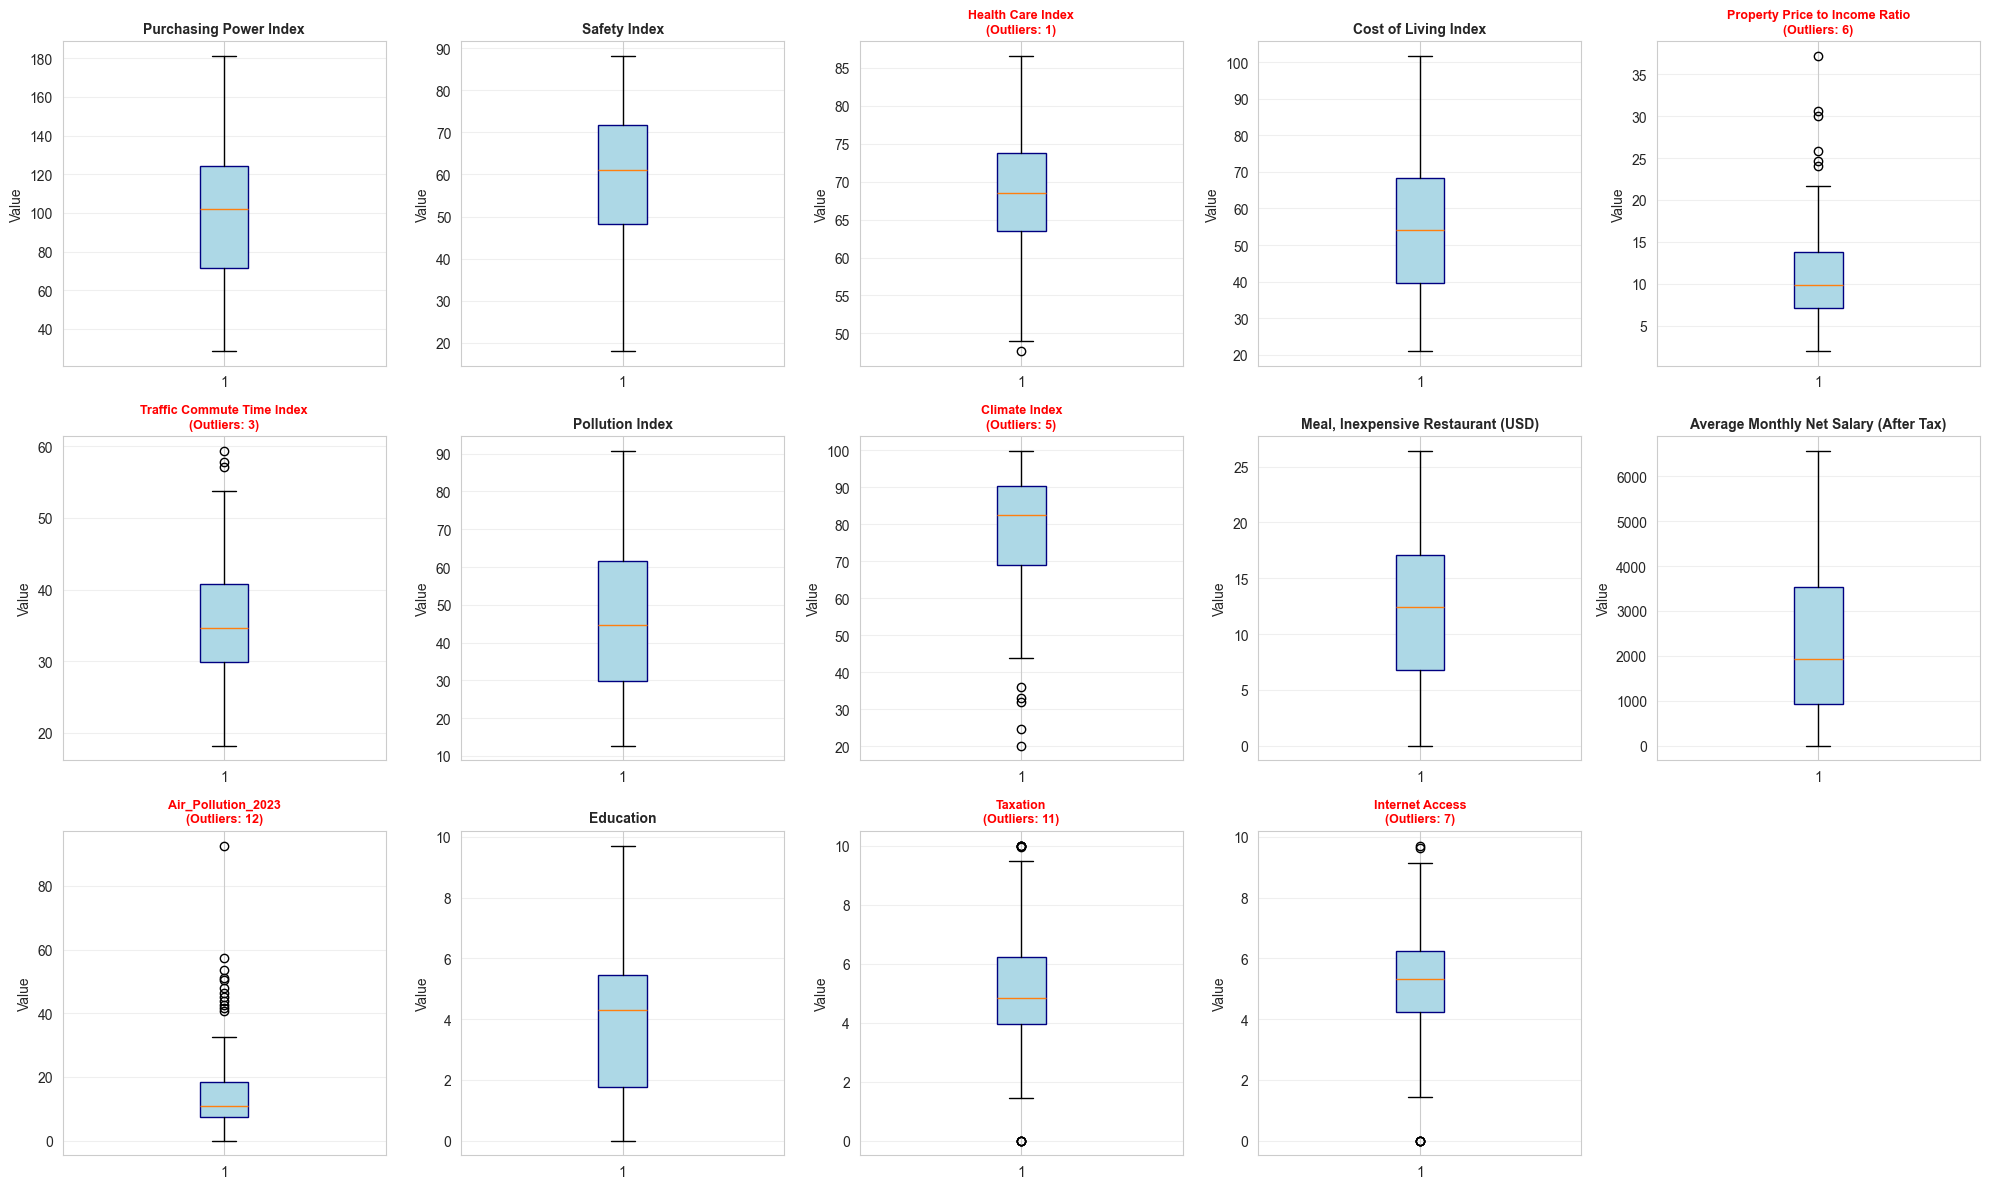

âœ“ Saved: outliers_boxplots.png


In [42]:
# Visualize outliers with box plots
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(all_numeric_features):
    # Create box plot
    bp = axes[idx].boxplot(df_processed[col], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_edgecolor('navy')
    
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add outlier count to title
    outlier_count = outlier_summary[col]['outlier_count']
    if outlier_count > 0:
        axes[idx].set_title(f"{col}\n(Outliers: {outlier_count})", fontsize=9, fontweight='bold', color='red')

# Hide unused subplots
for idx in range(len(all_numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/phase2/outliers_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("âœ“ Saved: outliers_boxplots.png")

## Section 7: Encode Categorical Variables (Label Encoding)

In [43]:
print("=" * 80)
print("CATEGORICAL ENCODING - LABEL ENCODING FOR COUNTRY")
print("=" * 80)

# Label encode Country
le_country = LabelEncoder()
df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

# Create country mapping dataframe
country_mapping = pd.DataFrame({
    'Country': le_country.classes_,
    'Encoded_Value': le_country.transform(le_country.classes_)
})

print(f"\nTotal unique countries: {len(le_country.classes_)}")
print(f"\nCountry to Label Encoding Mapping:")
print(country_mapping.to_string(index=False))

CATEGORICAL ENCODING - LABEL ENCODING FOR COUNTRY

Total unique countries: 67

Country to Label Encoding Mapping:
             Country  Encoded_Value
             Armenia              0
           Australia              1
             Austria              2
          Azerbaijan              3
             Belarus              4
             Belgium              5
BosniaAndHerzegovina              6
              Brazil              7
            Bulgaria              8
              Canada              9
               China             10
            Colombia             11
             Croatia             12
              Cyprus             13
       CzechRepublic             14
             Denmark             15
             Ecuador             16
             Estonia             17
             Finland             18
              France             19
             Georgia             20
             Germany             21
              Greece             22
     HongKong(China)  

## Section 8: Scale Numerical Features (StandardScaler)

In [44]:
print("=" * 80)
print("NUMERICAL FEATURE SCALING - STANDARDSCALER")
print("=" * 80)
print("\nMethod: StandardScaler (zero-mean, unit variance)")
print(f"Features to scale: {len(all_numeric_features)}\n")

# Apply StandardScaler
scaler = StandardScaler()
df_scaled = df_processed.copy()
df_scaled[all_numeric_features] = scaler.fit_transform(df_processed[all_numeric_features])

print(f"Scaling verification (target: mean â‰ˆ 0, std â‰ˆ 1):")
mean_scaled = df_scaled[all_numeric_features].mean().mean()
std_scaled = df_scaled[all_numeric_features].std().mean()
print(f"  Mean of all scaled features: {mean_scaled:.8f}")
print(f"  Std of all scaled features: {std_scaled:.8f}")

print(f"\nScaling statistics per feature:")
scaling_stats = pd.DataFrame({
    'Feature': all_numeric_features,
    'Mean': df_scaled[all_numeric_features].mean(),
    'Std': df_scaled[all_numeric_features].std(),
    'Min': df_scaled[all_numeric_features].min(),
    'Max': df_scaled[all_numeric_features].max()
})
print(scaling_stats.to_string(index=False))

NUMERICAL FEATURE SCALING - STANDARDSCALER

Method: StandardScaler (zero-mean, unit variance)
Features to scale: 14

Scaling verification (target: mean â‰ˆ 0, std â‰ˆ 1):
  Mean of all scaled features: 0.00000000
  Std of all scaled features: 1.00335009

Scaling statistics per feature:
                               Feature          Mean     Std       Min      Max
                Purchasing Power Index -1.598721e-16 1.00335 -1.978455 2.269527
                          Safety Index  5.536312e-16 1.00335 -2.898598 1.970524
                     Health Care Index  4.056015e-16 1.00335 -2.447663 2.324017
                  Cost of Living Index  1.421085e-16 1.00335 -1.846033 2.562219
        Property Price to Income Ratio -1.480297e-16 1.00335 -1.526130 4.513418
            Traffic Commute Time Index -1.598721e-16 1.00335 -2.141726 3.074173
                       Pollution Index  6.542914e-16 1.00335 -1.812858 2.363585
                         Climate Index  8.585725e-17 1.00335 -3.504181 1.

## Section 9: Create Final Dataset

In [45]:
print("=" * 80)
print("PREPARING FINAL PROCESSED DATASET")
print("=" * 80)

# Create final dataset with original identifiers and all processed features
final_df = df_scaled[['Rank', 'City', 'Country', 'Country_Encoded'] + all_numeric_features].copy()

print(f"\nFinal Dataset Shape: {final_df.shape}")
print(f"\nColumns in final dataset ({len(final_df.columns)} total):")
print(final_df.columns.tolist())

print(f"\nFirst 5 rows of processed data:")
print(final_df.head())

print(f"\nData types:")
print(final_df.dtypes)

print(f"\nMissing values: {final_df.isnull().sum().sum()}")

PREPARING FINAL PROCESSED DATASET

Final Dataset Shape: (150, 18)

Columns in final dataset (18 total):
['Rank', 'City', 'Country', 'Country_Encoded', 'Purchasing Power Index', 'Safety Index', 'Health Care Index', 'Cost of Living Index', 'Property Price to Income Ratio', 'Traffic Commute Time Index', 'Pollution Index', 'Climate Index', 'Meal, Inexpensive Restaurant (USD)', 'Average Monthly Net Salary (After Tax)', 'Air_Pollution_2023', 'Education', 'Taxation', 'Internet Access']

First 5 rows of processed data:
   Rank       City               Country  Country_Encoded  \
0   123       Lviv               Ukraine               62   
1   145       Baku            Azerbaijan                3   
2   135    Yerevan               Armenia                0   
3   124   Sarajevo  BosniaAndHerzegovina                6   
4    87  Hyderabad                 India               26   

   Purchasing Power Index  Safety Index  Health Care Index  \
0               -1.538336      0.136789          -0.81

## Section 10: Export Processed Dataset

In [46]:
print("=" * 80)
print("EXPORTING PROCESSED DATASET")
print("=" * 80)

# Export to CSV
final_df.to_csv('../data/processed/processed_livable_cities.csv', index=False)

print(f"\nSuccessfully exported: processed_livable_cities.csv")
print(f"  Shape: {final_df.shape}")
print(f"  Size: {final_df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"  Missing values: {final_df.isnull().sum().sum()}")

# Verify export
verification_df = pd.read_csv('../data/processed/processed_livable_cities.csv')
print(f"\n Verification successful:")
print(f"  Reimported shape: {verification_df.shape}")
print(f"  Reimported columns: {len(verification_df.columns)}")

EXPORTING PROCESSED DATASET

Successfully exported: processed_livable_cities.csv
  Shape: (150, 18)
  Size: 35.57 KB
  Missing values: 0

 Verification successful:
  Reimported shape: (150, 18)
  Reimported columns: 18


## Section 11: Summary Visualization

In [47]:
# Generate preprocessing report
report = f"""
================================================================================
PHASE 2: PREPROCESSING REPORT
================================================================================

Dataset: processed_livable_cities.csv
Rows: {len(final_df)} | Columns: {len(final_df.columns)}
Target: City ({len(final_df['City'].unique())} unique classes)
Features: {len(all_numeric_features)} (numerical, scaled)

DATA COMPLETENESS:
- Missing values before: {df.isnull().sum().sum()}
- Missing values after: {final_df.isnull().sum().sum()}

PREPROCESSING STEPS:
* Loaded raw merged dataset
* Analyzed {len(missing_stats_sorted)} columns with missing data
* Applied country-wise mean imputation
* Detected outliers using IQR method (kept for learning)
* Label encoded Country ({len(le_country.classes_)} unique)
* StandardScaled all {len(all_numeric_features)} features

OUTLIERS DETECTED:


{outlier_df_sorted[['outlier_count', 'outlier_percentage']].to_string() if len(outlier_df_sorted) > 0 else 'None'}

COUNTRY ENCODING MAPPING:
{country_mapping.to_string(index=False)}

FEATURE SCALING VERIFICATION:
- Mean: {mean_scaled:.8f} (target: 0)
- Std: {std_scaled:.8f} (target: 1)

FILES GENERATED:
1. processed_livable_cities.csv - Ready for Phase 3
2. missing_values_analysis.png
3. outliers_boxplots.png
4. preprocessing_summary.png

NEXT STEPS: Phase 3 - Model Development
================================================================================
"""

with open('preprocessing_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print(report)


PHASE 2: PREPROCESSING REPORT

Dataset: processed_livable_cities.csv
Rows: 150 | Columns: 18
Target: City (150 unique classes)
Features: 14 (numerical, scaled)

DATA COMPLETENESS:
- Missing values before: 109
- Missing values after: 0

PREPROCESSING STEPS:
* Loaded raw merged dataset
* Analyzed 6 columns with missing data
* Applied country-wise mean imputation
* Detected outliers using IQR method (kept for learning)
* Label encoded Country (67 unique)
* StandardScaled all 14 features

OUTLIERS DETECTED:


                                outlier_count  outlier_percentage
Air_Pollution_2023                       12.0            8.000000
Taxation                                 11.0            7.333333
Internet Access                           7.0            4.666667
Property Price to Income Ratio            6.0            4.000000
Climate Index                             5.0            3.333333
Traffic Commute Time Index                3.0            2.000000
Health Care Index         

## Section 12: Completion Status

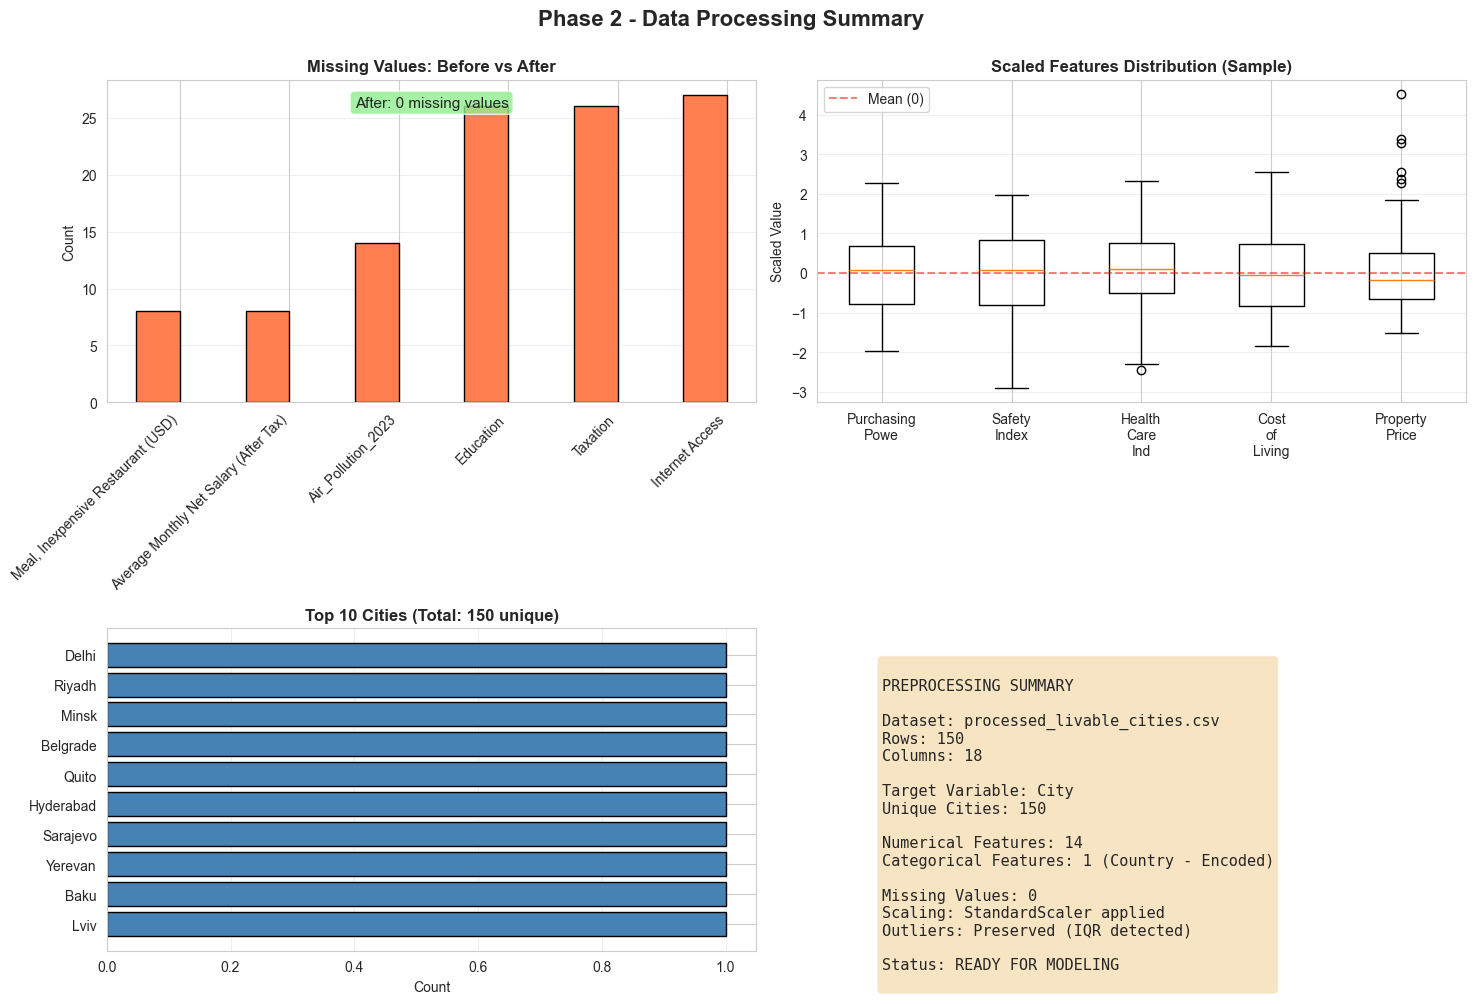

 Saved: preprocessing_summary.png


In [48]:
# Create summary visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Phase 2 - Data Processing Summary', fontsize=16, fontweight='bold', y=1.00)

# 1. Missing Values Before & After
ax1 = axes[0, 0]
missing_before = df.isnull().sum()[df.isnull().sum() > 0]
missing_after = final_df.isnull().sum()[final_df.isnull().sum() > 0]

x = range(len(missing_before))
ax1.bar([i - 0.2 for i in x], missing_before.values, width=0.4, label='Before', color='coral', edgecolor='black')
ax1.set_title('Missing Values: Before vs After', fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xticks(x)
ax1.set_xticklabels(missing_before.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.text(0.5, 0.95, 'After: 0 missing values', transform=ax1.transAxes, 
         ha='center', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# 2. Feature Scaling Distribution
ax2 = axes[0, 1]
sample_features = all_numeric_features[:5]
scaled_data = [df_scaled[col].values for col in sample_features]
ax2.boxplot(scaled_data, labels=[f.replace(' ', '\n')[:15] for f in sample_features])
ax2.set_title('Scaled Features Distribution (Sample)', fontweight='bold')
ax2.set_ylabel('Scaled Value')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Mean (0)')
ax2.legend()

# 3. Classes in Target Variable
ax3 = axes[1, 0]
city_counts = final_df['City'].value_counts().head(10)
ax3.barh(range(len(city_counts)), city_counts.values, color='steelblue', edgecolor='black')
ax3.set_yticks(range(len(city_counts)))
ax3.set_yticklabels(city_counts.index)
ax3.set_xlabel('Count')
ax3.set_title(f'Top 10 Cities (Total: {len(final_df["City"].unique())} unique)', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Dataset Summary Info
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
PREPROCESSING SUMMARY

Dataset: processed_livable_cities.csv
Rows: {len(final_df)}
Columns: {len(final_df.columns)}

Target Variable: City
Unique Cities: {len(final_df['City'].unique())}

Numerical Features: {len(all_numeric_features)}
Categorical Features: 1 (Country - Encoded)

Missing Values: {final_df.isnull().sum().sum()}
Scaling: StandardScaler applied
Outliers: Preserved (IQR detected)

Status: READY FOR MODELING
"""
ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../outputs/phase2/preprocessing_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Saved: preprocessing_summary.png")

## Phase 2 Complete!

In [49]:
print("\\n" + "="*70)
print("PHASE 2: PREPROCESSING - COMPLETE")
print("="*70)
print("\\ Generated Files:")
print("  1. processed_livable_cities.csv")
print("  2. missing_values_analysis.png")
print("  3. outliers_boxplots.png")
print("  4. preprocessing_summary.png")
print("  5. preprocessing_report.txt")
print("\\ Summary:")
print(f" Initial missing: {df.isnull().sum().sum()} â†’ Final: 0")
print(f" Outliers: {outlier_df['outlier_count'].sum()}")
print(f" Countries: {len(le_country.classes_)}")
print(f" Features scaled: {len(all_numeric_features)}")
print(f" Classes: {len(final_df['City'].unique())}")
print("\\Ready for Phase 3: Model Development")
print("="*70)

\n======================================================================
PHASE 2: PREPROCESSING - COMPLETE
\ Generated Files:
  1. processed_livable_cities.csv
  2. missing_values_analysis.png
  3. outliers_boxplots.png
  4. preprocessing_summary.png
  5. preprocessing_report.txt
\ Summary:
 Initial missing: 109 â†’ Final: 0
 Outliers: 45.0
 Countries: 67
 Features scaled: 14
 Classes: 150
\Ready for Phase 3: Model Development
